link dataset kaggle : https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("../../Data/emails.csv")
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


In [3]:
df.describe()

,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
count,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,...,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000
mean,6.640565,6.188128,5.143852,3.075599,3.124710,2.627030,55.517401,2.466551,2.024362,10.600155,...,0.005027,0.012568,0.010634,0.098028,0.004254,0.006574,0.004060,0.914733,0.006961,0.290023
std,11.745009,9.534576,14.101142,6.045970,4.680522,6.229845,87.574172,4.314444,6.967878,19.281892,...,0.105788,0.199682,0.116693,0.569532,0.096252,0.138908,0.072145,2.780203,0.098086,0.453817
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,12.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,3.000000,1.000000,1.000000,2.000000,1.000000,28.000000,1.000000,0.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,7.000000,4.000000,3.000000,4.000000,2.000000,62.250000,3.000000,1.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,210.000000,132.000000,344.000000,89.000000,47.000000,77.000000,1898.000000,70.000000,167.000000,223.000000,...,4.000000,7.000000,2.000000,12.000000,3.000000,4.000000,3.000000,114.000000,4.000000,1.000000


In [4]:
# Memisahkan fitur (X) dan target (y)
X = df.drop(['Email No.', 'Prediction'], axis=1)
y = df['Prediction']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nDistribusi kelas:")
print(y.value_counts())

Shape of X: (5172, 3000)
Shape of y: (5172,)

Distribusi kelas:
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [5]:
# Split data menjadi training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran data training:", X_train.shape)
print("Ukuran data testing:", X_test.shape)

Ukuran data training: (4137, 3000)
Ukuran data testing: (1035, 3000)


In [6]:
# Membuat dan melatih model SVM
# Menggunakan kernel 'linear' karena dataset besar
svm_model = SVC(kernel='linear', random_state=42)

print("Melatih model SVM...")
svm_model.fit(X_train, y_train)
print("Model berhasil dilatih!")

Melatih model SVM...
Model berhasil dilatih!


In [22]:
# Melakukan prediksi pada data testing
y_pred = svm_model.predict(X_test)


print("Prediksi selesai!")
print("\nContoh hasil prediksi (10 data pertama):")
print("Prediksi:", y_pred[:10])
print("Aktual  :", y_test.values[:10])

print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

Prediksi selesai!

Contoh hasil prediksi (10 data pertama):
Prediksi: [0 0 0 0 1 1 0 0 0 1]
Aktual  : [0 0 0 0 0 1 0 0 0 1]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       735
           1       0.94      0.95      0.94       300

    accuracy                           0.97      1035
   macro avg       0.96      0.96      0.96      1035
weighted avg       0.97      0.97      0.97      1035


Akurasi Model: 96.71%


Confusion Matrix:
[[716  19]
 [ 15 285]]


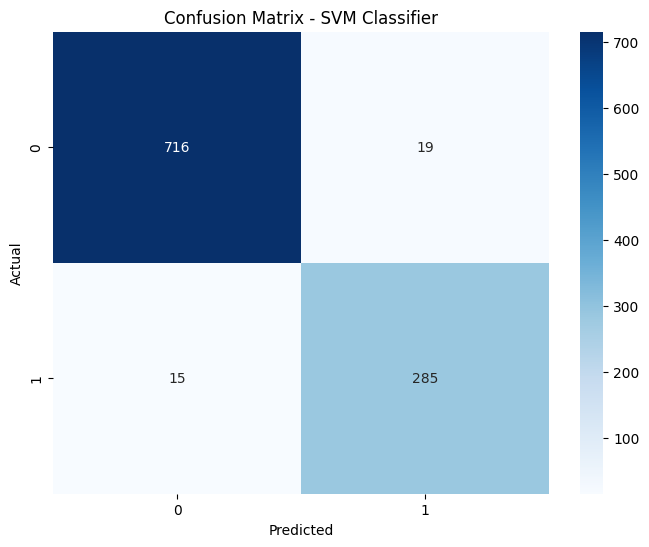

In [8]:
# Evaluasi model - Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Visualisasi Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - SVM Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       735
           1       0.94      0.95      0.94       300

    accuracy                           0.97      1035
   macro avg       0.96      0.96      0.96      1035
weighted avg       0.97      0.97      0.97      1035


Akurasi Model: 96.71%


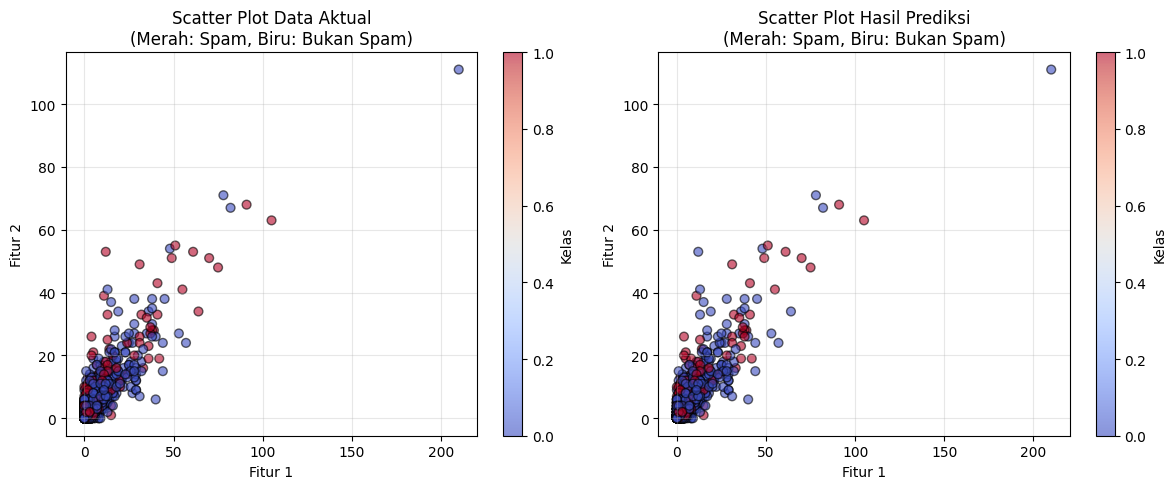

In [19]:
# Visualisasi Scatter Plot - 2 Fitur Pertama dengan Warna Berdasarkan Prediksi
plt.figure(figsize=(12, 5))

# Plot berdasarkan data aktual
plt.subplot(1, 2, 1)
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap='coolwarm', alpha=0.6, s=40, edgecolors='k')
plt.colorbar(label='Kelas')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.title('Scatter Plot Data Aktual\n(Merah: Spam, Biru: Bukan Spam)')
plt.grid(True, alpha=0.3)

# Plot berdasarkan prediksi
plt.subplot(1, 2, 2)
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, cmap='coolwarm', alpha=0.6, s=40, edgecolors='k')
plt.colorbar(label='Kelas')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.title('Scatter Plot Hasil Prediksi\n(Merah: Spam, Biru: Bukan Spam)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

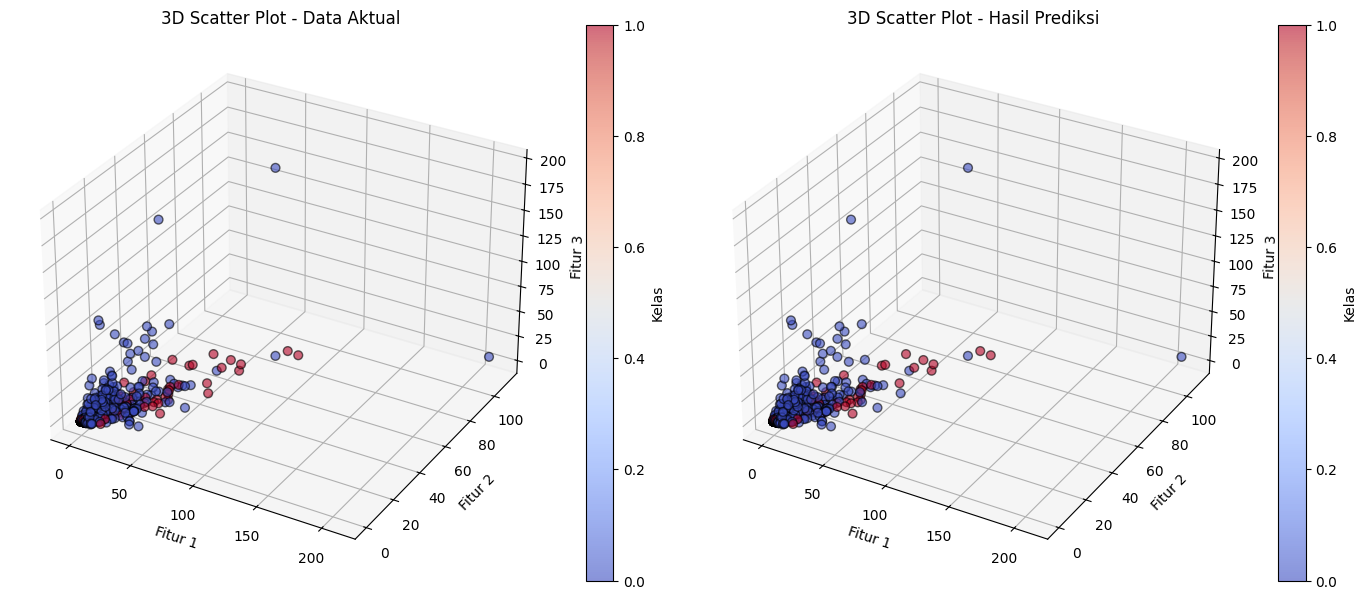

In [20]:
# Visualisasi 3D Scatter Plot - 3 Fitur Pertama
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# Plot 3D untuk data aktual
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], X_test.iloc[:, 2], 
                       c=y_test, cmap='coolwarm', s=40, alpha=0.6, edgecolors='k')
ax1.set_xlabel('Fitur 1')
ax1.set_ylabel('Fitur 2')
ax1.set_zlabel('Fitur 3')
ax1.set_title('3D Scatter Plot - Data Aktual')
plt.colorbar(scatter1, ax=ax1, label='Kelas')

# Plot 3D untuk prediksi
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], X_test.iloc[:, 2], 
                       c=y_pred, cmap='coolwarm', s=40, alpha=0.6, edgecolors='k')
ax2.set_xlabel('Fitur 1')
ax2.set_ylabel('Fitur 2')
ax2.set_zlabel('Fitur 3')
ax2.set_title('3D Scatter Plot - Hasil Prediksi')
plt.colorbar(scatter2, ax=ax2, label='Kelas')

plt.tight_layout()
plt.show()

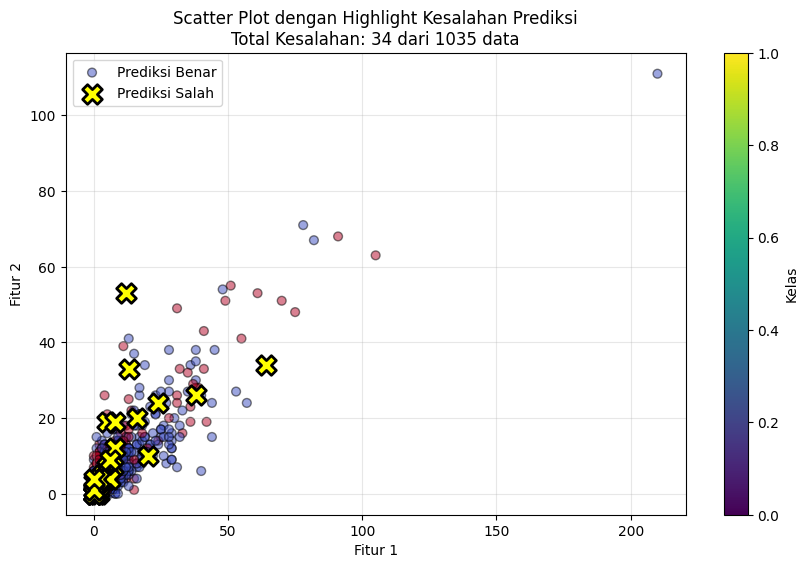


Jumlah prediksi benar: 1001
Jumlah prediksi salah: 34


In [21]:
# Scatter Plot untuk Kesalahan Prediksi (Misclassification)
# Membuat dataframe untuk analisis kesalahan
errors_df = pd.DataFrame({
    'Fitur_1': X_test.iloc[:, 0],
    'Fitur_2': X_test.iloc[:, 1],
    'Aktual': y_test.values,
    'Prediksi': y_pred,
    'Status': ['Benar' if y_test.values[i] == y_pred[i] else 'Salah' for i in range(len(y_pred))]
})

plt.figure(figsize=(10, 6))
# Plot prediksi yang benar
correct = errors_df[errors_df['Status'] == 'Benar']
plt.scatter(correct['Fitur_1'], correct['Fitur_2'], c=correct['Aktual'], 
           cmap='coolwarm', alpha=0.5, s=40, edgecolors='k', label='Prediksi Benar')

# Plot prediksi yang salah (misclassification)
incorrect = errors_df[errors_df['Status'] == 'Salah']
plt.scatter(incorrect['Fitur_1'], incorrect['Fitur_2'], 
           color='yellow', marker='X', s=200, edgecolors='black', 
           linewidths=2, label='Prediksi Salah', zorder=5)

plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.title(f'Scatter Plot dengan Highlight Kesalahan Prediksi\nTotal Kesalahan: {len(incorrect)} dari {len(y_pred)} data')
plt.colorbar(label='Kelas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nJumlah prediksi benar: {len(correct)}")
print(f"Jumlah prediksi salah: {len(incorrect)}")

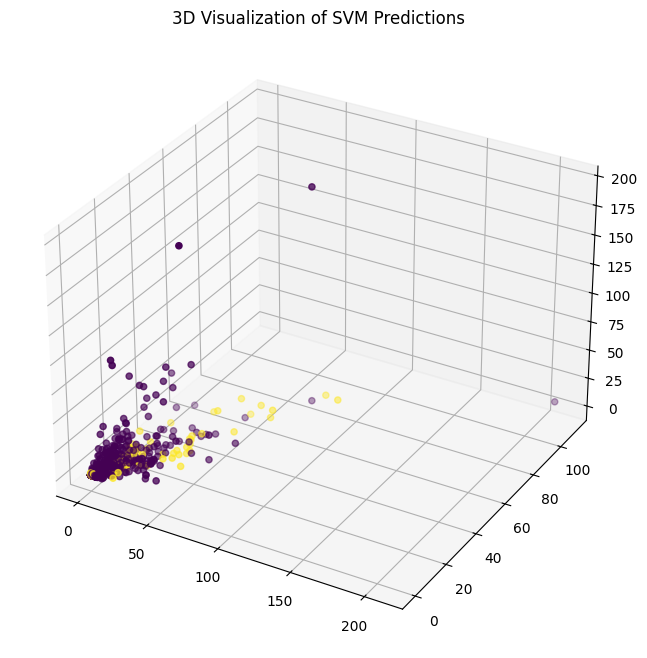

In [ ]:
# Visualisasi Scatter Plot - Distribusi Prediksi vs Aktual
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, alpha=0.5, label='Aktual', color='blue', s=30)
plt.scatter(range(len(y_pred)), y_pred, alpha=0.5, label='Prediksi', color='red', marker='x', s=30)
plt.xlabel('Index Data')
plt.ylabel('Kelas (0: Bukan Spam, 1: Spam)')
plt.title('Scatter Plot: Perbandingan Prediksi vs Aktual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()# Visualisasi 3D dari beberapa fitur
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], X_test.iloc[:, 2], c=y_pred, cmap='viridis', marker='o')
ax.set_title('3D Visualization of SVM Predictions')
plt.show()